In [1]:
# %load  PROSTATE_Classification.py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import h5py
import json
import numpy as np
import random
from sklearn.model_selection import train_test_split
import torchvision.models as models
# from segment_anything import sam_model_registry
import torch.nn.functional as F
from tqdm import tqdm
import os
from torchvision import transforms
from torch.nn.parallel import DataParallel 

## Configuration

In [2]:
# ============== MODEL & Training Set=================
model_name = "Omnirad_vit_fusion"   
run = 1 #993:transformer;994:pool;995:CNN;996:cat;992:None
trick_num = 5
DataParallel = False        
device = torch.device("cuda:0")
num_epochs = 150
batch_size = 16 #32/16 available for resnet and 2 for MedSAM
num_splits = 5 # 1 for no kfold
DATA_EXTAND = False
SupCon = False
seed=42
num_workers=4

In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
seed_everything(seed)
g = torch.Generator()
g.manual_seed(seed)

In [4]:
trick_list = {
    0: "8: 2 train-test split",
    1: "horizontal flip & 5° rotate",
    2: "elastic deformation",
    3: "lr schedule",
    4: "0 & 1",
    5: "0 & 1 & 2",
    6: "Mask_12 & 0",
    7: "Mask_12 & 0 & 1",
    8: "0 & 2",
    9: "0 & crop",
    10: "0 & True Mask",#v1.2
    11: "0 & True Mask 12",
    12: "0 & SAM3 Mask 0.5", #run2:horizonal flip & random rotate
    13: "0 & SAM3 MASK 0.6", #run1:ori
    14: "VIT 0 & SAM3 MASK 0.6",#run1:ori run2:elastic
    15: "VIT 0"#run1:ori, run2:horizonal flip & random rotate
}
save_path = f"./run1.4/{model_name}/{trick_num}/{run}" #1.2 for k-fold，1.3 for data_extand, 1.4 for contrastive learning, 1.5 for v1.0dataset
if not os.path.exists(save_path):
    os.makedirs(save_path)
    print("Directory created:", save_path)
else:
    print("Directory already exists:", save_path)
for i in range(num_splits):
    fold_dir = os.path.join(save_path,f"fold_{i}")
    os.makedirs(fold_dir,exist_ok=True)
    print(f"Created folder: {fold_dir}")

Directory already exists: ../run1.4/Omnirad_vit_fusion/5/1
Created folder: ../run1.4/Omnirad_vit_fusion/5/1/fold_0
Created folder: ../run1.4/Omnirad_vit_fusion/5/1/fold_1
Created folder: ../run1.4/Omnirad_vit_fusion/5/1/fold_2
Created folder: ../run1.4/Omnirad_vit_fusion/5/1/fold_3
Created folder: ../run1.4/Omnirad_vit_fusion/5/1/fold_4


* "normal_prostate": 0
* "benign_prostate_cancer": 1
* "non_significant_prostate_cancer":2
* "significant_prostate_cancer": 3, 

V1.1
- [x] mask预存
- [x] 8：2分割，无验证集
- [x] 1e-2开始，decay0.1every30；savery every 3 after 1e-4;
- [x] 数据增强：小幅旋转5°/左右翻转/
- [x] 弹性形变
- [x] kfold training
- [x] Data Expand
- [ ] Supervised constrast learning

## MODELS

In [5]:
"""
h5py dataset structure:
    /<patient_index>/
        label   : int scalar (0..3)
        ADC     : (16,1024,1024,1) float32 (values normalized in [0,1])
        DWI     : (16,1024,1024,1) float32
        T2      : (16,1024,1024,1) float32
        ADC_res : (16,224,224,1) float32 (values normalized in [0,1])
        DWI_res : (16,224,224,1) float32
        T2_res  : (16,224,224,1) float32
        mask_res : (16,224,224,1) float32
        mask_res_12 : (16,224,224,1) float32
        T2_res_sam3_text_mask_0.5: 
        T2_res_sam3_text_mask_o.6: 
        attrs: orig_shape_ADC, orig_shape_DWI, orig_shape_T2 (strings)
"""


# Define the classification model
class MRIClassifier(nn.Module):
    def __init__(self, num_classes=4, proj_dim=128):
        super().__init__()
        self.mask_generator = None
        
        # ResNet with shared weights
        resnet = models.resnet50(weights=None)
        ckpt = torch.load('./weights/resnet50-11ad3fa6.pth', map_location=torch.device('cpu'))
        # 假设保存的是 state_dict
        resnet.load_state_dict(ckpt)
        # Modify ResNet to accept 4 channels
        resnet.conv1 = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # Remove the original classification head
        self.slice_processor = nn.Sequential(*list(resnet.children())[:-1])
        
        # Classification head
        self.fc = nn.Linear(resnet.fc.in_features, num_classes)

        # projection head for contrastive loss
        self.proj_head = nn.Sequential(
            nn.Linear(resnet.fc.in_features,resnet.fc.in_features),
            nn.ReLU(),
            nn.Linear(resnet.fc.in_features, proj_dim)
        )
        # ImageNet normalization
        # self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406, 0.5], std=[0.229, 0.224, 0.225, 0.225])


    def forward(self, adc, dwi, t2, mask = None):
        # adc, dwi, t2 are (B, 16, 1, H, W)
        # t2_hr is (B, 16, 1, H_hr, W_hr)
        
        x = torch.cat([adc, dwi, t2, mask], dim=2) # (B, 16, 4, H, W)
        
        B, S, C, H, W = x.shape

        # Process each slice with shared weights
        # Reshape to (B*S, C, H, W) for ResNet
        x = x.view(B * S, C, H, W) # (B*16, 4, H, W)

        # x = self.normalize(x) MRI数据特殊，就先不进行归一化了
        
        slice_features = self.slice_processor(x) # (B*16, 2048, 1, 1) for resnet50
        slice_features = slice_features.view(B * S, -1) # (B*16, 2048)
        
        
        # Get classification logits for each slice
        slice_outputs = self.fc(slice_features) # (B*16, num_classes)

        # Reshape to separate batch and slice dimensions
        slice_outputs = slice_outputs.view(B, S, -1) # (B, 16, num_classes)

        # Sum the logits across slices for a final decision
        output = torch.sum(slice_outputs, dim=1) # (B, num_classes)
        
        proj = F.normalize(self.proj_head(slice_features), dim=1)
        return output, proj

In [6]:
import timm

In [7]:
class VITClassifier(nn.Module):
    def __init__(
        self,
        vit_name='vit_base_patch16_224',
        num_classes=4,
        pretrained=False,
        vit_ckpt=None,     # 离线权重路径
        use_mask=True,
        fusion=None,
        proj_dim=128,
        nhead=8,
        num_layers=2,
        num_slices=16
    ):
        super().__init__()

        self.use_mask = use_mask

        # ViT backbone（去掉分类头）
        self.vit = timm.create_model(
            vit_name,
            pretrained=False,
            num_classes=0,     # 输出 embedding
            global_pool='avg'#TODO: 1. 查看timm如何构造 2. 在class_token和fc之间+全局池化
        )

        embed_dim = self.vit.num_features

        self.fusion = fusion

        # -------- 位置编码 --------
        if fusion is not None:
            self.pos_embed = nn.Parameter(
                torch.randn(1, num_slices, embed_dim)
            )

        # -------- Transformer --------
        if fusion == "transformer":
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=nhead,
                batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(
                encoder_layer,
                num_layers=num_layers,
            )
                # ---- CNN fusion ----
        if fusion == "cnn":
            self.slice_cnn = nn.Sequential(
                nn.Conv1d(embed_dim, embed_dim, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv1d(embed_dim, embed_dim, kernel_size=3, padding=1),
                nn.ReLU(),
            )
        if fusion == "cat":
            self.catclassifier = nn.Sequential(
                nn.Linear(num_slices * embed_dim, 512),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(512, num_classes)
            )
        # -------- 分类头 --------
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, num_classes),
        )
        
        # slice-level classifier
        self.fc = nn.Linear(embed_dim, num_classes)

        # projection head for contrastive loss
        self.proj_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, proj_dim)
        )
        # 加载离线权重（可选）
        if vit_ckpt is not None:
            state_dict = torch.load(vit_ckpt, map_location='cpu')
            state_dict.pop('head.weight', None)
            state_dict.pop('head.bias', None)
            self.vit.load_state_dict(state_dict, strict=False)

    def forward(self, adc, dwi, t2, mask=None):
        """
        adc, dwi, t2: (B, S, 1, H, W)
        mask:         (B, S, 1, H, W) or None
        """

        B, S, _, H, W = adc.shape

        # ---- mask processing ----
        if self.use_mask and mask is not None:
            mask_proc = mask.float()   # 0.0 / 1.0
            adc = adc * mask_proc
            dwi = dwi * mask_proc
            t2  = t2  * mask_proc

        # ---- concat modalities (channel dim) ----
        # (B, S, 3, H, W)
        x = torch.cat([adc, dwi, t2], dim=2)

        # ---- slice as batch ----
        # (B*S, 3, H, W)
        x = x.view(B * S, 3, H, W)

        # ---- ViT slice features ----
        # (B*S, embed_dim)
        slice_features = self.vit(x)

        if self.fusion is None:
            # ---- slice logits ----
            # (B*S, num_classes)
            slice_logits = self.fc(slice_features)

            # ---- reshape back ----
            # (B, S, num_classes)
            slice_logits = slice_logits.view(B, S, -1)

            # ---- aggregate over slices ----
            # (B, num_classes)
            output = torch.sum(slice_logits, dim=1)
        elif self.fusion =="transformer":
            feat = slice_features.view(B, S, -1)
            # 加位置编码
            feat = feat + self.pos_embed[:, :S, :]
            feat = self.transformer(feat)

            pooled = feat.mean(dim=1)
            output = self.classifier(pooled)
        
        # =========================
        # Pool Fusion
        # =========================
        elif self.fusion == "pool":
            feat = slice_features.view(B, S, -1)
            # mean pooling
            pooled = feat.mean(dim=1)   # (B, E)

            # 如果想用 max：
            # pooled, _ = feat.max(dim=1)

            output = self.classifier(pooled)

        # =========================
        # CNN Fusion
        # =========================
        elif self.fusion == "cnn":
            feat = slice_features.view(B, S, -1)
            # Conv1d expects (B, C, S)
            feat = feat.permute(0, 2, 1)   # (B, E, S)

            feat = self.slice_cnn(feat)    # (B, E, S)

            # global average over slices
            pooled = feat.mean(dim=2)      # (B, E)

            output = self.classifier(pooled)
        elif self.fusion == "cat":

            feat = slice_features.view(B, S, -1)
            feat = feat.flatten(start_dim=1) 

            output = self.catclassifier(feat)
        else:
            raise ValueError("Invalid fusion mode")

        proj = F.normalize(self.proj_head(slice_features), dim=1)
        
        
        return output,proj

In [8]:
class BioVITClassifier(nn.Module):
    def __init__(
        self,
        vit_name='vit_base_patch16_224',
        num_classes=4,
        pretrained=False,
        vit_ckpt=None,     # 离线权重路径
        use_mask=False,
        fusion=None,
        proj_dim=128,
        nhead=8,
        num_layers=2,
        num_slices=16
    ):
        super().__init__()

        self.use_mask = use_mask

        # ViT backbone（去掉分类头）
        if vit_name == "Biomedclip_vit":
            self.vit = torch.load(vit_ckpt,map_location=device,weights_only=False)
            embed_dim = 512#512
        elif vit_name == "Omnirad_vit": 
            model_omnirad = timm.create_model("hf_hub:Snarcy/OmniRad-base",pretrained=False)
            state = torch.load(vit_ckpt, map_location="cpu",weights_only=True)
            model_omnirad.load_state_dict(state,strict=True)
            model_omnirad.reset_classifier(0)#768
            self.vit = model_omnirad
            embed_dim = self.vit.num_features

        self.fusion = fusion

        # -------- 位置编码 --------
        if fusion is not None:
            self.pos_embed = nn.Parameter(
                torch.randn(1, num_slices, embed_dim)
            )

        # -------- Transformer --------
        if fusion == "transformer":
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=nhead,
                batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(
                encoder_layer,
                num_layers=num_layers,
            )
        # -------- 分类头 --------
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, num_classes),
        )
        
        # slice-level classifier
        self.fc = nn.Linear(embed_dim, num_classes)

        # projection head for contrastive loss
        self.proj_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, proj_dim)
        )
        # 加载离线权重（可选）
        # if vit_ckpt is not None:
        #     state_dict = torch.load(vit_ckpt, map_location='cpu')
        #     state_dict.pop('head.weight', None)
        #     state_dict.pop('head.bias', None)
        #     self.vit.load_state_dict(state_dict, strict=False)

    def forward(self, adc, dwi, t2, mask=None):
        """
        adc, dwi, t2: (B, S, 1, H, W)
        mask:         (B, S, 1, H, W) or None
        """

        B, S, _, H, W = adc.shape

        # ---- mask processing ----
        if self.use_mask and mask is not None:
            mask_proc = mask.float()   # 0.0 / 1.0
            adc = adc * mask_proc
            dwi = dwi * mask_proc
            t2  = t2  * mask_proc

        # ---- concat modalities (channel dim) ----
        # (B, S, 3, H, W)
        x = torch.cat([adc, dwi, t2], dim=2)

        # ---- slice as batch ----
        # (B*S, 3, H, W)
        x = x.view(B * S, 3, H, W)

        # ---- ViT slice features ----
        # (B*S, embed_dim)
        slice_features = self.vit(x)

        if self.fusion is None:
            # ---- slice logits ----
            # (B*S, num_classes)
            slice_logits = self.fc(slice_features)

            # ---- reshape back ----
            # (B, S, num_classes)
            slice_logits = slice_logits.view(B, S, -1)

            # ---- aggregate over slices ----
            # (B, num_classes)
            output = torch.sum(slice_logits, dim=1)
        elif self.fusion =="transformer":
            feat = slice_features.view(B, S, -1)
            # 加位置编码
            feat = feat + self.pos_embed[:, :S, :]
            feat = self.transformer(feat)

            pooled = feat.mean(dim=1)
            output = self.classifier(pooled)
        
        proj = F.normalize(self.proj_head(slice_features), dim=1)
        
        
        return output,proj

In [9]:
# ResNet 
# Define the classification model
class ResNetClassifier(nn.Module):
    def __init__(self, num_classes=4,crop_ratio=0.75,input_size=224,use_mask=True,fusion=None,proj_dim=128,nhead=8,num_layers=2,num_slices=16):
        super().__init__()
       
        # ResNet with shared weights
        resnet = models.resnet50(weights=None)
        ckpt = torch.load('./weights/resnet50-11ad3fa6.pth', map_location=torch.device('cpu'))
        # 假设保存的是 state_dict
        resnet.load_state_dict(ckpt)
        # Modify ResNet to accept 3 channels
        resnet.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # Remove the original classification head
        self.slice_processor = nn.Sequential(*list(resnet.children())[:-1])
        
        # Classification head
        self.fc = nn.Linear(resnet.fc.in_features, num_classes)

        # ImageNet normalization
        # self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406, 0.5], std=[0.229, 0.224, 0.225, 0.225])
        self.crop_ratio = crop_ratio
        self.input_size = input_size
        
        # 预先创建一个 Mask，注册为 buffer (不会被更新，但在 state_dict 中)
        self.register_buffer('mask', self._create_mask())
        
        self.use_mask = use_mask
        
        # projection head for contrastive loss
        self.proj_head = nn.Sequential(
            nn.Linear(resnet.fc.in_features,resnet.fc.in_features),
            nn.ReLU(),
            nn.Linear(resnet.fc.in_features,proj_dim)
        )
        
        self.fusion=fusion
        embed_dim=resnet.fc.in_features
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim,embed_dim//2),
            nn.GELU(),
            nn.Linear(embed_dim//2,num_classes)
        )
        if fusion is not None:
            self.pos_embed = nn.Parameter(
                torch.randn(1,num_slices,embed_dim)
            )
        if fusion == "transformer":
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=nhead,
                batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(
                encoder_layer,
                num_layers=num_layers,
            )

        

    def _create_mask(self):
        mask = torch.zeros((1, 3, self.input_size, self.input_size))
        
        # 计算中心区域的坐标
        center = self.input_size // 2
        crop_size = int(self.input_size * self.crop_ratio)
        start = center - crop_size // 2
        end = start + crop_size
        
        # 将中心区域设为 1
        mask[:, :, start:end, start:end] = 1.0
        return mask

    def forward(self, adc, dwi, t2, mask=None):
        # adc, dwi, t2 are (B, 16, 1, H, W)
        # t2_hr is (B, 16, 1, H_hr, W_hr)
        

        if self.use_mask:
            mask_proc = mask  # 用合适方式得到 mask_proc
            mask_proc = mask_proc.float()     # 0.0 / 1.0
            

            # 对所有通道 / modalities 做 elementwise multiplication
            adc = adc * mask_proc
            dwi = dwi * mask_proc
            t2  = t2  * mask_proc

            # 然后再 concat (不把 mask 当通道)
            x = torch.cat([adc, dwi, t2], dim=2)
        else:
            # Concatenate along channel dimension (dim=2)
            x = torch.cat([adc, dwi, t2], dim=2) # (B, 16, 3, H, W)
        
        B, S, C, H, W = x.shape
        

        x = x.view(B * S, C, H, W) # (B*16, 3, H, W)

        # x = self.normalize(x) MRI数据特殊，就先不进行归一化了
        
        slice_features = self.slice_processor(x) # (B*16, 2048, 1, 1) for resnet50
        slice_features = slice_features.view(B * S, -1) # (B*16, 2048)
        
        if self.fusion is None:
            # Get classification logits for each slice
            slice_outputs = self.fc(slice_features) # (B*16, num_classes)

            # Reshape to separate batch and slice dimensions
            slice_outputs = slice_outputs.view(B, S, -1) # (B, 16, num_classes)

            # Sum the logits across slices for a final decision
            output = torch.sum(slice_outputs, dim=1) # (B, num_classes)
        elif self.fusion=="transformer":
            feat = slice_features.view(B, S, -1)
            feat = feat + self.pos_embed[:,:S,:]
            feat = self.transformer(feat)
            
            pooled = feat.mean(dim=1)
            output = self.classifier(pooled)
        proj = F.normalize(self.proj_head(slice_features), dim=1)
        return output,proj

## DATASET and TRAIN、EVALUATION Function

In [10]:
# Dataset class for HDF5
class MRIDataset(Dataset):
    def __init__(self, hdf5_path, patient_indices, use_rescaled=True):
        self.hdf5_path = hdf5_path
        self.patient_indices = patient_indices
        self.use_rescaled = use_rescaled
        self.file = None

    def __len__(self):
        return len(self.patient_indices)

    def __getitem__(self, idx):
        if self.file is None:
            self.file = h5py.File(self.hdf5_path, 'r')
            
        patient_index = self.patient_indices[idx]
        patient_group = self.file[str(patient_index)]
        
        label = patient_group['label'][()]
        
        item = {'label': torch.tensor(label, dtype=torch.long)}

        if self.use_rescaled:
            adc = patient_group['ADC_res'][:] # (16, 224, 224, 1)
            dwi = patient_group['DWI_res'][:]
            t2 = patient_group['T2_res'][:]
            mask = patient_group['T2_res_sam3_text_mask_0.6'][:] # (16, 1024, 1024, 1)
            
            # Permute from (S, H, W, C) to (S, C, H, W) for PyTorch
            item['adc'] = torch.from_numpy(adc).float().permute(0, 3, 1, 2)
            item['dwi'] = torch.from_numpy(dwi).float().permute(0, 3, 1, 2)
            item['t2'] = torch.from_numpy(t2).float().permute(0, 3, 1, 2)
            item['mask'] = torch.from_numpy(mask).float().permute(0, 3, 1, 2)
        else:
            adc = patient_group['ADC'][:] # (16, 1024, 1024, 1)
            dwi = patient_group['DWI'][:]
            t2 = patient_group['T2'][:]
            
            # Permute from (S, H, W, C) to (S, C, H, W) for PyTorch
            item['adc'] = torch.from_numpy(adc).float().permute(0, 3, 1, 2)
            item['dwi'] = torch.from_numpy(dwi).float().permute(0, 3, 1, 2)
            item['t2'] = torch.from_numpy(t2).float().permute(0, 3, 1, 2)
            # No t2_hr needed if not using rescaled, as t2 is already high-res
            
        return item

In [11]:
from torchvision.transforms import InterpolationMode
def train(model, train_loader, optimizer, criterion, device, supcon_loss=None):
    model.train()
    # Keep mask generator in eval mode
    if model == MRIClassifier():
        model.module.mask_generator.eval()
    total_loss = 0
    for batch in tqdm(train_loader, desc="Training"):
        adc_batch = batch['adc'].to(device)
        dwi_batch = batch['dwi'].to(device)
        t2_batch = batch['t2'].to(device)
        labels = batch['label'].to(device)
        mask_batch = batch.get('mask')
        B, S, C, H, W = t2_batch.shape
        if mask_batch is not None:
            mask_batch = mask_batch.to(device)
        
        # Apply augmentation to each item in the batch individually
        for i in range(adc_batch.shape[0]):
            adc = adc_batch[i]
            dwi = dwi_batch[i]
            t2 = t2_batch[i]
            if mask_batch is not None:
                mask = mask_batch[i]

            #1. Random Horizontal Flip
            if torch.rand(1) < 0.5:
                adc = transforms.functional.hflip(adc)
                dwi = transforms.functional.hflip(dwi)
                t2 = transforms.functional.hflip(t2)
                if mask_batch is not None:
                    mask = transforms.functional.hflip(mask)
            
            # Elastic deform
#             elastic = transforms.ElasticTransform(alpha=50.0, sigma=5.0, interpolation=transforms.InterpolationMode.BILINEAR, fill=0)

#             # 在训练/augmentation pipeline 中：
#             if torch.rand(1) < 0.3:
#                 adc  = elastic(adc)
#                 dwi  = elastic(dwi)
#                 t2   = elastic(t2)
#                 if mask_batch is not None:
#                     mask = elastic(mask)
                

            #2. Random Rotation
            angle = transforms.RandomRotation.get_params(degrees=(-15, 15))
            adc = transforms.functional.rotate(adc, angle)
            dwi = transforms.functional.rotate(dwi, angle)
            t2 = transforms.functional.rotate(t2, angle)
            if mask_batch is not None:
                mask = transforms.functional.rotate(mask, angle)

            adc_batch[i] = adc
            dwi_batch[i] = dwi
            t2_batch[i] = t2
            if mask_batch is not None:
                mask_batch[i] = mask
                
            #3. translation + scale
            scale = random.uniform(0.9, 1.1)

            max_dx = 0.1 * W
            max_dy = 0.1 * H

            translate = (
                random.uniform(-max_dx, max_dx),
                random.uniform(-max_dy, max_dy)
            )

            adc = transforms.functional.affine(adc,angle=0,translate=translate,scale=scale,shear=[0, 0],interpolation=InterpolationMode.BILINEAR)
            dwi = transforms.functional.affine(dwi,angle=0,translate=translate,scale=scale,shear=[0, 0],interpolation=InterpolationMode.BILINEAR)
            t2 = transforms.functional.affine(t2,angle=0,translate=translate,scale=scale,shear=[0, 0],interpolation=InterpolationMode.BILINEAR)
            if mask is not None:
                mask = transforms.functional.affine(mask,angle=0,translate=translate,scale=scale,shear=[0, 0],interpolation=InterpolationMode.NEAREST)
                
        
        optimizer.zero_grad()
        
        outputs,proj = model(adc_batch, dwi_batch, t2_batch, mask=mask_batch)
        loss = criterion(outputs, labels)
        
        if supcon_loss is not None:
            alpha = 0.5
            labels_rep = labels.unsqueeze(1).repeat(1,16).view(-1)  # (B*16,)
            loss_supcon = supcon_loss(proj, labels_rep)
            loss = loss + alpha*loss_supcon
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    return total_loss / len(train_loader)

In [12]:
def validate(model, val_loader, criterion, device,supcon_loss=None):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation"):
            adc = batch['adc'].to(device)
            dwi = batch['dwi'].to(device)
            t2 = batch['t2'].to(device)
            labels = batch['label'].to(device)
            mask = batch.get('mask')
            if mask is not None:
                mask = mask.to(device)

            outputs,proj = model(adc, dwi, t2, mask=mask)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    return total_loss / len(val_loader), accuracy

In [13]:
from sklearn.metrics import recall_score
def joint_recall(y_true, y_pred, positive_labels=(2,3)):
    """
    Compute recall for a set of positive labels.
    A prediction is correct if it falls into positive_labels,
    regardless of which specific label inside that set.
    """
    y_true_bin = [1 if y in positive_labels else 0 for y in y_true]
    y_pred_bin = [1 if y in positive_labels else 0 for y in y_pred]
    return recall_score(y_true_bin, y_pred_bin)

In [14]:
def evaluate(model, data_loader, device, dataset_name, save_path=None, plt_title='None',plt_show=False):
    model.eval()
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc=f"Evaluating on {dataset_name}"):
            adc = batch['adc'].to(device)
            dwi = batch['dwi'].to(device)
            t2 = batch['t2'].to(device)
            labels = batch['label'].to(device)
            mask = batch.get('mask')
            if mask is not None:
                mask = mask.to(device)

            outputs,proj = model(adc, dwi, t2, mask=mask)
            _, predicted = torch.max(outputs.data, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            
    print(f"\n--- Evaluation Report for {dataset_name} ---")
    # Assuming classes are 0, 1, 2, 3
    target_names = [f'Class {i}' for i in range(4)]#4:num_classes
    report_dict = classification_report(all_labels, all_predictions, target_names=target_names, output_dict=True) 

    acc = report_dict["accuracy"]
    
    # recall for all classes
    # print(report_dict.keys())
    class_acc = {str(c): report_dict[f'Class {c}']["recall"] for c in range(4)}#4:num_classes
    

    # print(classification_report(all_labels, all_predictions, target_names=target_names))
    
    cm = confusion_matrix(all_labels, all_predictions)
    
    # 可视化混淆矩阵
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {plt_title}')
    plt.colorbar()
    
    # 设置刻度标签
    tick_marks = np.arange(len(target_names))
    plt.xticks(tick_marks, target_names, rotation=45)
    plt.yticks(tick_marks, target_names)
    
    # 在格子中显示数值
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], 'd'),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    if save_path is not None:

        # 保存图像
        plt.savefig(f"{save_path}_confusion_matrix.png",dpi=300, bbox_inches='tight')  # savefig 会根据扩展名自动推断格式📌
        print(f"Saved plot to: {save_path}_confusion_matrix.png")
    if plt_show:
        plt.show()
    cancer_recall = joint_recall(all_labels, all_predictions)
    #print(f"Joint recall for classes 2&3: {recall:.2f}")
    return acc, class_acc, cancer_recall

## MODEL Initialization

In [15]:
vit_ckpt='./weights/vit_base_patch16_224.pth'

vit_large_ckpt='./weights/vit_large_patch16_224.pth'
vit_large_in21k_ckpt='./weights/vit_large_patch16_224_in21k.pth'
vit_huge_ckpt='./weights/vit_huge_patch14_224.pth'
vit_huge_mae_ckpt='./weights/vit_huge_patch14_224.mae.pth'
swin_ckpt='./weights/swin_base_patch4_window7_224.pth'
biomedclip_vit_ckpt='./weights/biomedclip_visual_full.pt'
omnirad_vit_ckpt='./weights/OmniRad-base_weights.pth'


MODEL_MAP = {
    "ResNetClassifier": ResNetClassifier,
    "ResNetfusion": ResNetClassifier,
    "MRIClassifier": MRIClassifier,
    "VITClassifier":VITClassifier,
    "VITBasefusion":VITClassifier,
    "VITLargeClassifier":VITClassifier,
    "VITLargefusion":VITClassifier,
    "VITLarge21kClassifier":VITClassifier,
    "VITHugeClassifier":VITClassifier,
    "VITHugefusion":VITClassifier,
    "VITHugeMaefusion":VITClassifier,
    "SWINClassifier":VITClassifier,
    "SWINfusion":VITClassifier,
    "Biomedclip_vit":BioVITClassifier,
    "Omnirad_vit":BioVITClassifier,
    "Biomedclip_vit_fusion":BioVITClassifier,
    "Omnirad_vit_fusion":BioVITClassifier,
}

def build_model(name):
    ModelClass = MODEL_MAP[name]
    # 根据不同模型构建传参
    if name == "ResNetClassifier":
        return ModelClass()
    if name == "ResNetfusion":
        return ModelClass(use_mask=True,fusion="transformer")
    if name == "MRIClassifier":
        return ModelClass()
    if name == "Biomedclip_vit":
        return ModelClass(vit_name='Biomedclip_vit',vit_ckpt=biomedclip_vit_ckpt)
    if name == "Omnirad_vit":
        return ModelClass(vit_name='Omnirad_vit',vit_ckpt=omnirad_vit_ckpt)
    if name == "Biomedclip_vit_fusion":
        return ModelClass(vit_name='Biomedclip_vit',vit_ckpt=biomedclip_vit_ckpt,fusion="transformer",use_mask=True)
    if name == "Omnirad_vit_fusion":
        return ModelClass(vit_name='Omnirad_vit',vit_ckpt=omnirad_vit_ckpt,fusion="transformer",use_mask=True)
    if name == "VITClassifier":
        return ModelClass(vit_ckpt=vit_ckpt)
    if name == "VITBasefusion":
        return ModelClass(vit_ckpt=vit_ckpt,fusion="transformer")
    if name == "VITLargeClassifier":
        return ModelClass(vit_name="vit_large_patch16_224", vit_ckpt=vit_large_ckpt)
    if name == "VITLargefusion":
        return ModelClass(vit_name="vit_large_patch16_224",vit_ckpt=vit_large_ckpt,fusion="cat")
    if name == "VITLarge21kClassifier":
        return ModelClass(vit_name="vit_large_patch16_224_in21k", vit_ckpt=vit_large_in21k_ckpt)
    if name == "VITHugeClassifier":
        return ModelClass(vit_name="vit_huge_patch14_224",vit_ckpt=vit_huge_ckpt)
    if name == "VITHugefusion":
        return ModelClass(vit_name="vit_huge_patch14_224",vit_ckpt=vit_huge_ckpt,fusion="cnn")
    if name == "VITHugeMaefusion":
        return ModelClass(vit_name="vit_huge_patch14_224.mae",vit_ckpt=vit_huge_mae_ckpt,fusion="transformer")
    if name == "SWINClassifier":
        return ModelClass(vit_name="swin_base_patch4_window7_224", vit_ckpt=swin_ckpt)
    if name == "SWINfusion":
        return ModelClass(vit_name="swin_base_patch4_window7_224", vit_ckpt=swin_ckpt, fusion="transformer")

In [16]:
def get_state_dict_for_saving(model: nn.Module):
    """返回应该给 torch.save 的 state_dict（处理 DataParallel 的 module）"""
    if hasattr(model, "module"):
        return model.module.state_dict()
    else:
        return model.state_dict()

## Loss

In [17]:
class SupConLoss(torch.nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        # features: [B, dim]  （已经是 normalized）
        # labels:   [B]
        B = features.shape[0]

        # 相似度矩阵
        sim_matrix = torch.exp(torch.mm(features, features.T) / self.temperature)

        # label mask 正负样本掩码
        label_mask = labels.unsqueeze(1) == labels.unsqueeze(0)
        neg_mask = ~label_mask

        # 排除自身对比
        sim_matrix = sim_matrix * (1 - torch.eye(B, device=features.device))

        # 分子是同类对比
        pos_sim = sim_matrix * label_mask

        # 分母是所有非自身对比
        denom = sim_matrix.sum(dim=1, keepdim=True)

        # 损失
        loss = -torch.log(pos_sim.sum(dim=1) / denom.squeeze())
        return loss.mean()

## Training

In [18]:
hdf5_path = './prostate_classification/patients_dataset_v1.0.h5'

# 不存在时创建一个虚假文件，为确保跑通
if not os.path.exists(hdf5_path):
    print(f"Error: HDF5 file not found at {hdf5_path}")
    print("Please provide the correct path to your HDF5 dataset.")
    # As a placeholder, create a dummy file
    print("Creating a dummy HDF5 file for demonstration purposes.")
    with h5py.File(hdf5_path, 'w') as f:
        for i in range(343):
            p_group = f.create_group(str(i))
            p_group.create_dataset('label', data=np.random.randint(0, 4))
            p_group.create_dataset('ADC', data=np.random.rand(16, 1024, 1024, 1).astype(np.float32))
            p_group.create_dataset('DWI', data=np.random.rand(16, 1024, 1024, 1).astype(np.float32))
            p_group.create_dataset('T2', data=np.random.rand(16, 1024, 1024, 1).astype(np.float32))
            p_group.create_dataset('ADC_res', data=np.random.rand(16, 224, 224, 1).astype(np.float32))
            p_group.create_dataset('DWI_res', data=np.random.rand(16, 224, 224, 1).astype(np.float32))
            p_group.create_dataset('T2_res', data=np.random.rand(16, 224, 224, 1).astype(np.float32))
            p_group.create_dataset('mask_res',data=np.random.rand(16,224,224,1).astypre(np.float32))
    print("Dummy file created.")

In [19]:
true_indices = []
false_indices = []

with h5py.File(hdf5_path, "r") as f:
    for k in f.keys():
        # is_early = f[k].attrs["early_stage_cancer"]
        # if bool(is_early):
            true_indices.append(int(k))
        # else:
        #     false_indices.append(int(k))

In [20]:
# 3. Dataset splitting
with h5py.File(hdf5_path, "r") as f:
    n = len(f)                      # 顶层 key 的数量
    print(f"dataset length: {n}")
    patient_indices = np.arange(n)
    labels = np.array([
        f[str(i)]["label"][()] for i in patient_indices
    ])
    labels_true = np.array([labels[i] for i in true_indices]) 
    labels_false =np.array([labels[i] for i in false_indices]) 
    print(f"Early_stage dataset length: {labels_true.size}")
    print(f"Extand dataset length: {labels_false.size}")

dataset length: 344
Early_stage dataset length: 344
Extand dataset length: 0


### Kfold Training

#### split function 

In [21]:
from sklearn.model_selection import StratifiedKFold, train_test_split
def build_splits(
    patient_indices,
    labels,
    num_splits,
    test_size=0.2,
    seed=42
):
    patient_indices = np.asarray(patient_indices)
    labels = np.asarray(labels)

    if num_splits >= 2:
        skf = StratifiedKFold(
            n_splits=num_splits,
            shuffle=True,
            random_state=seed
        )
        for fold, (tr, te) in enumerate(
            skf.split(patient_indices, labels)
        ):
            yield fold, patient_indices[tr], patient_indices[te]

    elif num_splits == 1:
        tr, te = train_test_split(
            patient_indices,
            test_size=test_size,
            stratify=labels,
            random_state=seed,
            shuffle=True
        )
        yield 0, tr, te

    else:
        raise ValueError("num_splits must be >= 1")

### 

In [22]:
indices = true_indices
for fold, train_idx, test_idx in build_splits(indices,labels_true,num_splits=num_splits):
    print(f"Fold {fold}:")

    if DATA_EXTAND:
        train_idx = np.concatenate([train_idx,np.array(false_indices)])
    train_labels = labels[train_idx]
    test_labels = labels[test_idx]
    print(" Train class counts:", np.bincount(train_labels))
    print(" Test class counts:", np.bincount(test_labels))

    # Dataloaders
    # Using rescaled data (224x224) for memory efficiency
    use_rescaled_data = True 
    train_dataset = MRIDataset(hdf5_path, train_idx, use_rescaled=use_rescaled_data)
    test_dataset = MRIDataset(hdf5_path, test_idx, use_rescaled=use_rescaled_data)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers,worker_init_fn=seed_worker,generator=g)  # numworkers启动多个并行的子进程预加载，解决I/O时间问题。但会带来内存开销的问题，可以调控RAM和GPU占用来平衡速度与开销
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers,worker_init_fn=seed_worker,generator=g)

    # ================== Model ===================
    model = build_model(model_name)
    model = model.to(device)

    if DataParallel and torch.cuda.device_count() > 1:
        print(f"[INFO] Using DataParallel with {torch.cuda.device_count()} GPUs.")
        model = torch.nn.DataParallel(model, device_ids=[0,1])
    
    if model_name == "MRIClassifier":
        if DataParallel:
            for param in model.module.mask_generator.parameters():
                param.requires_grad = False
            model.module.mask_generator.eval()
        else:
            for param in model.mask_generator.parameters():
                param.requires_grad = False
            model.mask_generator.eval()#其实在mask_generator类中本身已经如此配置过了
    
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
    # scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
    criterion = nn.CrossEntropyLoss()
    
    supcon_loss = SupConLoss(temperature=0.07) if SupCon else None
    

    logs = {
        "epoch": [],
        "train_loss": [],
        "test_loss": [],
        "test_acc": []
    }

    # =================== Training loop ===================
    best_test_acc = float(0)
    for epoch in range(num_epochs):
        train_loss = train(model, train_loader, optimizer, criterion, device,supcon_loss)
        test_loss, test_acc = validate(model, test_loader, criterion, device,supcon_loss)
    
        logs["epoch"].append(epoch)
        logs["train_loss"].append(train_loss)
        logs["test_loss"].append(test_loss)
        logs["test_acc"].append(test_acc)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, test Acc: {test_acc:.2f}%, LR: {current_lr}")
    
        # if epoch % 10 ==0 and current_lr >1e-4:
        #     checkpoint = get_state_dict_for_saving(model)
        #     torch.save(checkpoint, f'{save_path}/fold_{fold}/{run}_{epoch}.pth')
        if current_lr <= 1e-4:
            if (epoch + 1) % 100 == 0:
                torch.save(model.state_dict(), f'{save_path}/fold_{fold}/{run}_{epoch}.pth')
                print(f"Saved model at epoch {epoch+1} as per schedule.")

            
        # scheduler.step()
        if test_acc >= best_test_acc:
            best_test_acc = test_acc
            checkpoint = get_state_dict_for_saving(model)
            torch.save(checkpoint, f'{save_path}/fold_{fold}/{run}_best_model.pth')
            print(f"Saved best model of {model_name}.")

    with open(f"{save_path}/fold_{fold}/{run}_training_log.json", "w") as f:
        json.dump(logs, f, indent=4)

Fold 0:
 Train class counts: [54 79 61 81]
 Test class counts: [14 20 15 20]


Validation: 100%|██████████| 5/5 [00:03<00:00,  1.29it/s]


Epoch 1/150, Train Loss: 1.3820, Test Loss: 1.2957, test Acc: 42.03%, LR: 1e-05
Saved best model of Omnirad_vit_fusion.


Validation: 100%|██████████| 5/5 [00:04<00:00,  1.11it/s]


Epoch 2/150, Train Loss: 1.2828, Test Loss: 1.2483, test Acc: 43.48%, LR: 1e-05
Saved best model of Omnirad_vit_fusion.


...

Epoch 148/150, Train Loss: 0.0007, Test Loss: 2.4106, test Acc: 50.00%, LR: 1e-05


Validation: 100%|██████████| 5/5 [00:04<00:00,  1.24it/s]


Epoch 149/150, Train Loss: 0.0007, Test Loss: 2.4163, test Acc: 50.00%, LR: 1e-05


Validation: 100%|██████████| 5/5 [00:04<00:00,  1.23it/s]

Epoch 150/150, Train Loss: 0.0007, Test Loss: 2.4197, test Acc: 50.00%, LR: 1e-05


### Evaluation

In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [24]:
# model = MRIClassifier()
model = build_model(model_name)
acc_list = []
all_class_acc = []
all_cancer_recall = []

 Train class counts: [54 79 61 81]
 Test class counts: [14 20 15 20]


Evaluating on Test Set: 100%|██████████| 5/5 [00:07<00:00,  1.41s/it]



--- Evaluation Report for Test Set ---
Saved plot to: ../run1.4/Omnirad_vit_fusion/5/1/fold_0/fold_0_confusion_matrix.png


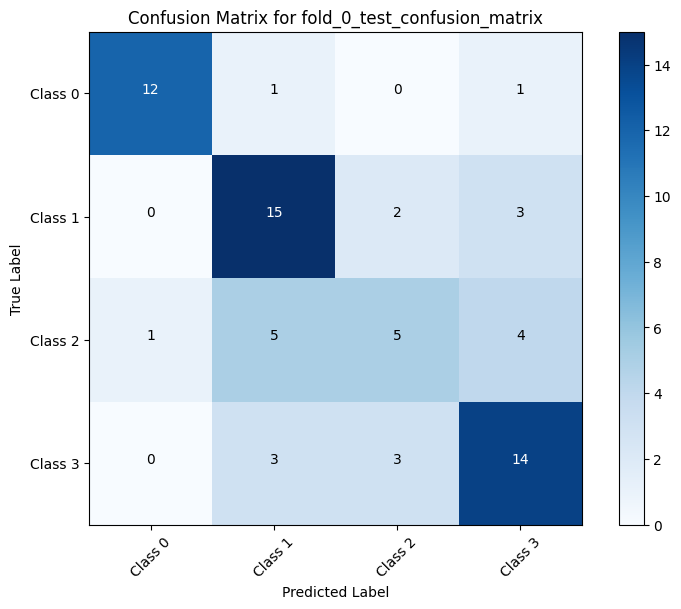

 Train class counts: [54 79 61 81]
 Test class counts: [14 20 15 20]


Evaluating on Test Set: 100%|██████████| 5/5 [00:07<00:00,  1.41s/it]



--- Evaluation Report for Test Set ---
Saved plot to: ../run1.4/Omnirad_vit_fusion/5/1/fold_1/fold_1_confusion_matrix.png
 Train class counts: [54 79 61 81]
 Test class counts: [14 20 15 20]


Evaluating on Test Set: 100%|██████████| 5/5 [00:06<00:00,  1.37s/it]



--- Evaluation Report for Test Set ---
Saved plot to: ../run1.4/Omnirad_vit_fusion/5/1/fold_2/fold_2_confusion_matrix.png
 Train class counts: [55 79 61 80]
 Test class counts: [13 20 15 21]


Evaluating on Test Set: 100%|██████████| 5/5 [00:06<00:00,  1.39s/it]



--- Evaluation Report for Test Set ---
Saved plot to: ../run1.4/Omnirad_vit_fusion/5/1/fold_3/fold_3_confusion_matrix.png
 Train class counts: [55 80 60 81]
 Test class counts: [13 19 16 20]


Evaluating on Test Set: 100%|██████████| 5/5 [00:06<00:00,  1.38s/it]



--- Evaluation Report for Test Set ---
Saved plot to: ../run1.4/Omnirad_vit_fusion/5/1/fold_4/fold_4_confusion_matrix.png
======== Test Accuracy ========
[0.6666666666666666, 0.6666666666666666, 0.5797101449275363, 0.5942028985507246, 0.5147058823529411]
[0.7428571428571429, 0.6571428571428571, 0.8571428571428571, 0.6388888888888888, 0.6111111111111112]
Average: 0.6043904518329071
STD: 0.05746804270491312
cancer_recall: 0.7014285714285714
STD: 0.08943483138719348
Average per-class acc across folds: {'0': np.float64(0.8516483516483516), '1': np.float64(0.6673684210526316), '2': np.float64(0.35750000000000004), '3': np.float64(0.5638095238095238)}


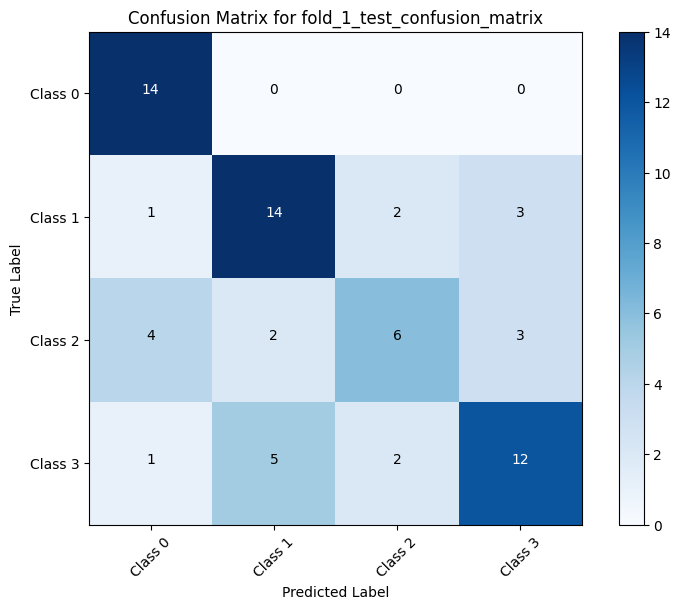

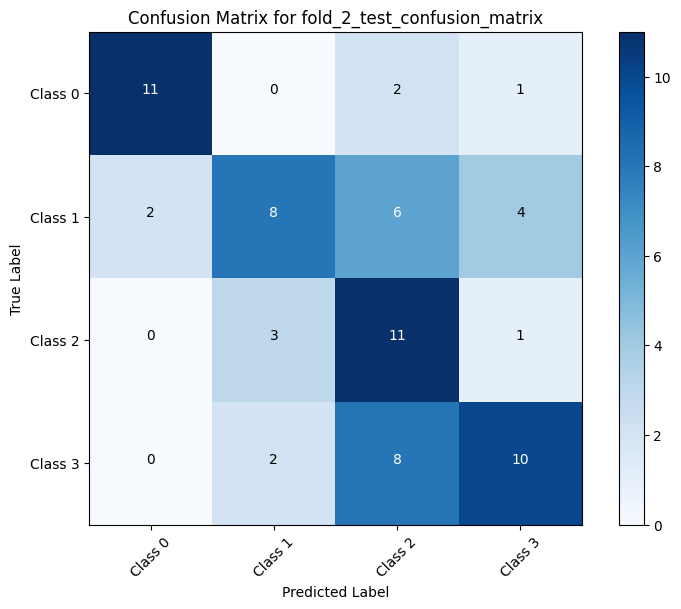

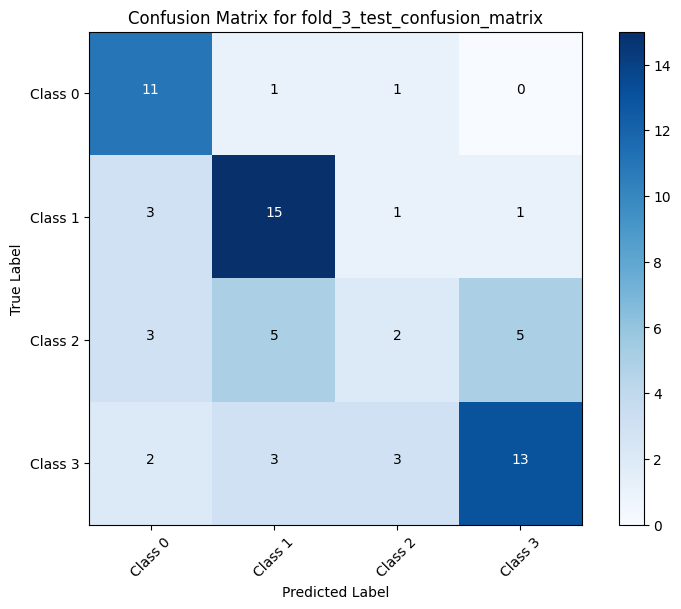

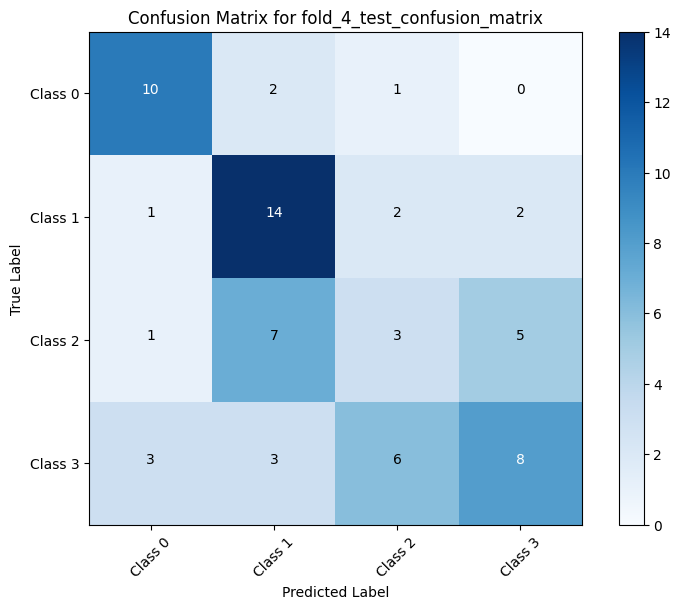

In [25]:
for fold, train_idx, test_idx in build_splits(indices,labels_true,num_splits=num_splits):

    if DATA_EXTAND:
        train_idx = np.concatenate([train_idx,np.array(false_indices)])
    train_labels = labels[train_idx]
    test_labels = labels[test_idx]
    print(" Train class counts:", np.bincount(train_labels))
    print(" Test class counts:", np.bincount(test_labels))

    # Dataloaders
    # Using rescaled data (224x224) for memory efficiency
    use_rescaled_data = True 
    train_dataset = MRIDataset(hdf5_path, train_idx, use_rescaled=use_rescaled_data)
    test_dataset = MRIDataset(hdf5_path, test_idx, use_rescaled=use_rescaled_data)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)  # numworkers启动多个并行的子进程预加载，解决I/O时间问题。但会带来内存开销的问题，可以调控RAM和GPU占用来平衡速度与开销
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    state = torch.load(f"{save_path}/fold_{fold}/{run}_best_model.pth", map_location=device)
    model.load_state_dict(state)
    model = model.to(device)
    # 3. 放到 GPU，再 wrap DataParallel
    if DataParallel and torch.cuda.device_count() > 1:
        print(f"[INFO] Using DataParallel with {torch.cuda.device_count()} GPUs.")
        model = torch.nn.DataParallel(model, device_ids=[0,1])
    # --- Evaluation ---
    plt_show = True if fold == 0 else False
    acc,class_acc,cancer_recall = evaluate(model, test_loader, device, "Test Set",save_path=f"{save_path}/fold_{fold}/fold_{fold}",plt_title=f"fold_{fold}_test_confusion_matrix",plt_show=plt_show)
    acc_list.append(acc)
    all_class_acc.append(class_acc)
    all_cancer_recall.append(cancer_recall)


print(f"======== Test Accuracy ========")
print(acc_list)
avg = sum(acc_list) / len(acc_list)
print(all_cancer_recall)
cancer_recall = sum(all_cancer_recall)/len(all_cancer_recall)

print("Average:", avg)
print("STD:", np.std(acc_list))
print("cancer_recall:",cancer_recall)
print("STD:", np.std(all_cancer_recall))


avg_acc = {}
for c in range(4):#4:num_classes
    vals = [fold_acc[str(c)] for fold_acc in all_class_acc]
    avg_acc[str(c)] = np.mean(vals)


print("Average per-class acc across folds:", avg_acc)

### Overview of training

In [26]:
# split_index = 0

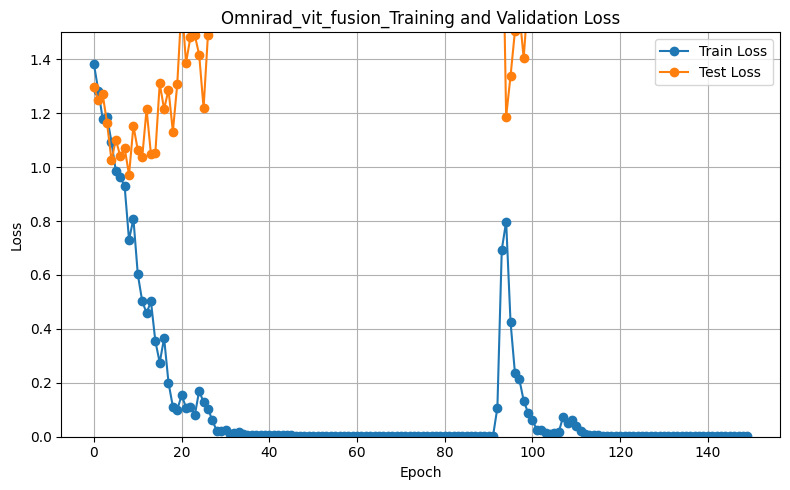

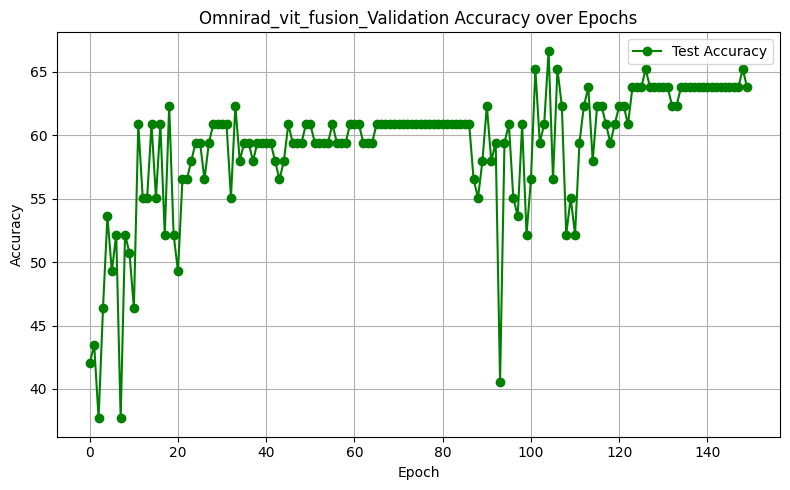

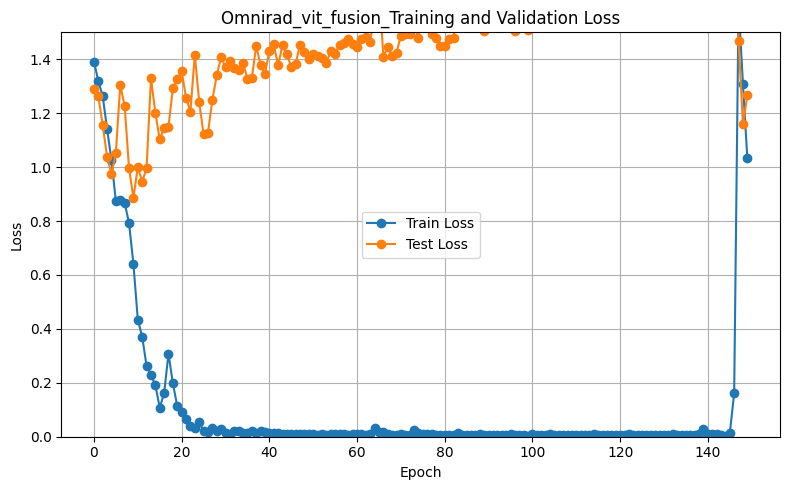

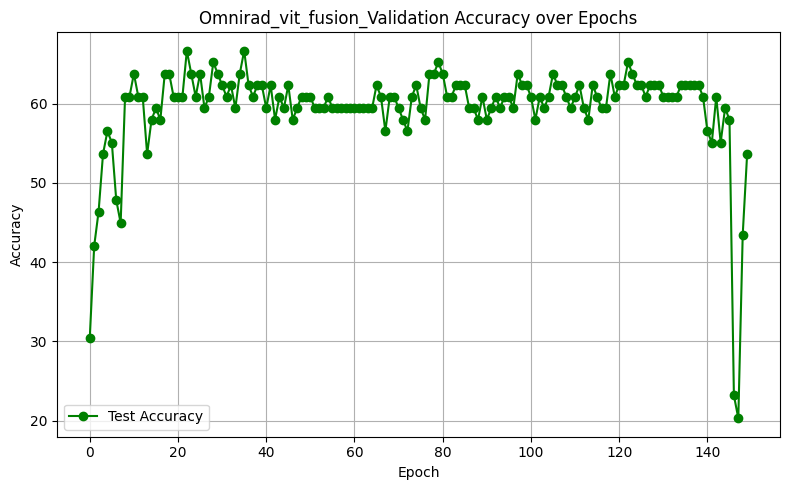

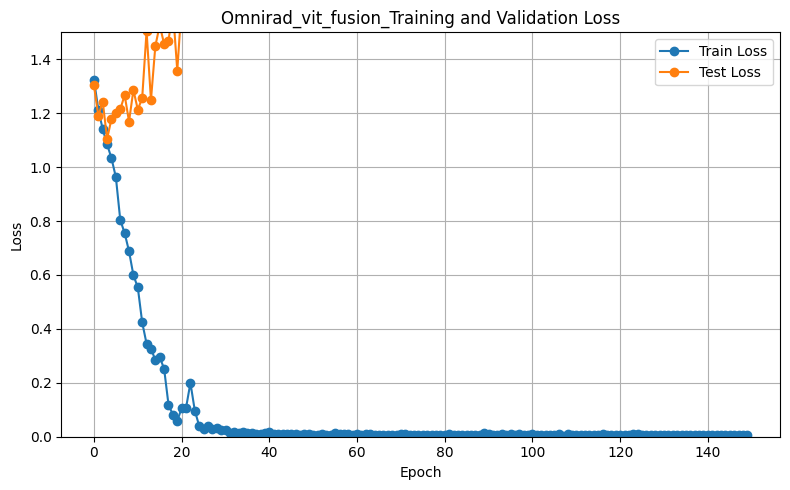

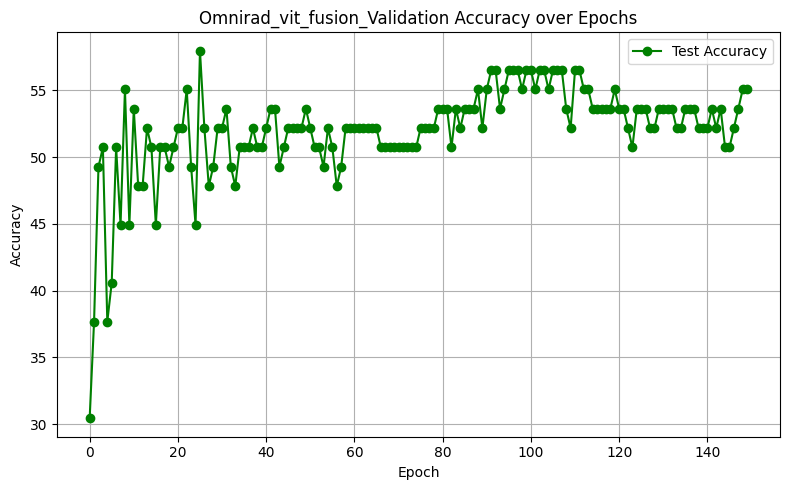

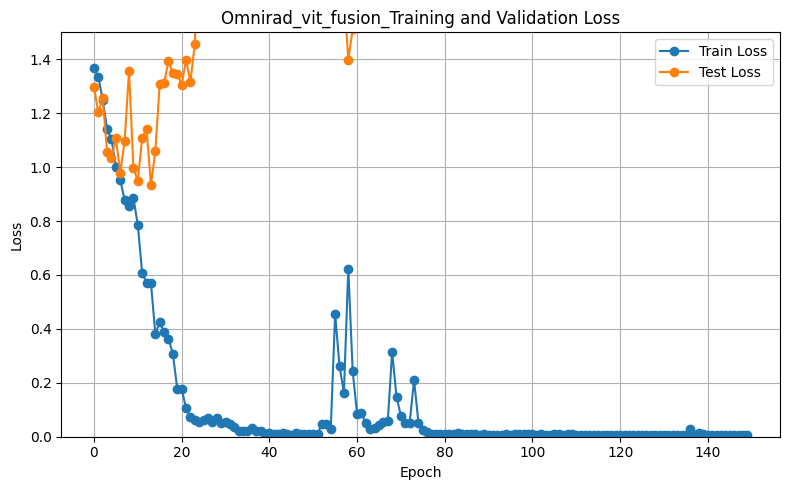

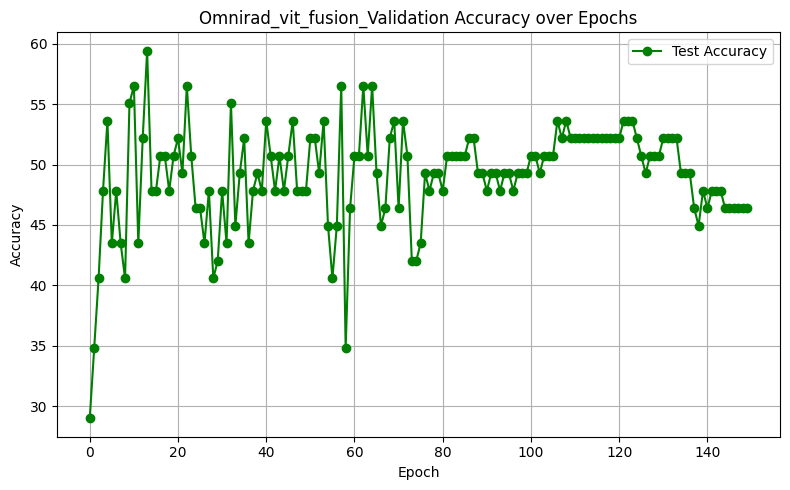

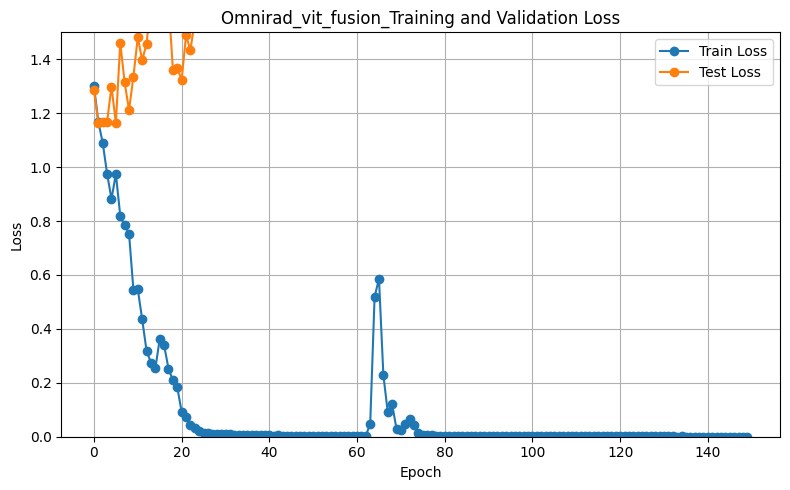

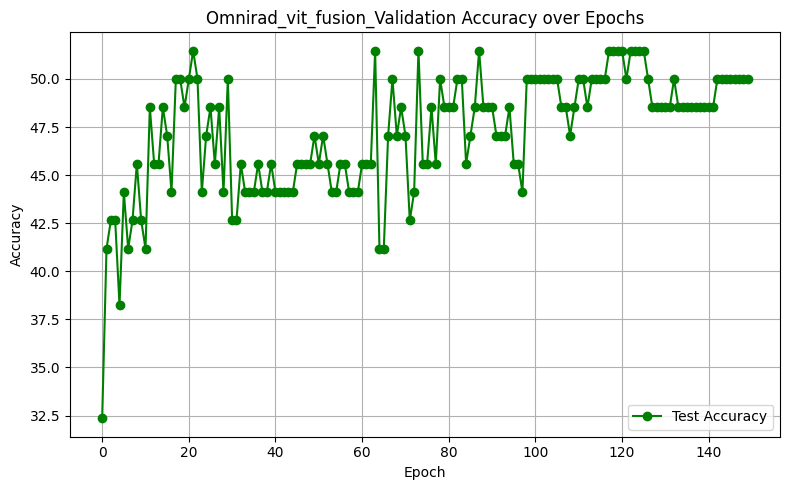

In [27]:
# 假设你的 JSON 存在一个文件里，比如 history.json
for split_index in range(num_splits):
    with open(f'{save_path}/fold_{split_index}/{run}_training_log.json', 'r') as f:
        history = json.load(f)

# 假设 JSON 结构类似：
# {
#   "epoch": [1, 2, 3, ...],
#   "train_loss": [ ... ],
#   "val_loss": [ ... ],
#   "val_acc": [ ... ]
# }

    epochs = history['epoch']
    train_loss = history['train_loss']
    val_loss = history['test_loss']
    val_acc = history['test_acc']

    # 绘制 loss 曲线
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, label='Train Loss', marker='o')
    plt.plot(epochs, val_loss, label='Test Loss', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.ylim(0,1.5)
    plt.title(f'{model_name}_Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()  # 布局紧凑
    plt.savefig(f"{save_path}/fold_{split_index}/Tra_Val_Loss.png", dpi=300, bbox_inches='tight')
    plt.show()

    # 绘制 accuracy 曲线（这里只画 validation accuracy，如果你还记录了 train acc，也可以加上去）
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, val_acc, label='Test Accuracy', marker='o', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name}_Validation Accuracy over Epochs')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{save_path}/fold_{split_index}/Tra_Val_Acc.png", dpi=300, bbox_inches='tight')
    plt.show()